In [1]:
import sys

sys.path.append("../..")
# imports
from datetime import date, timedelta
import itertools
import json
from matplotlib import pyplot as plt
import numpy as np
import polars as pl
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
import time

from analysis.datasets.stocks import load_dataset, append_future_returns
from analysis.db.queries import run_custom_query
from analysis.return_classification.decision_tree import DecisionTreeConfig, search_hyperparameters
from etl.transformation.silver import GoodSymbolsSilver
from etl.transformation.gold import StocksDailyGold


DATAPLATFORM_ROOT = "../../dataplatform"

In [ ]:
FEATURE_LIST = [
    "log_return_1d",
    "log_return_1w",
    "log_return_1m",
    "log_return_30_steps",
    # "log_return_1q",
    # "log_return_6m",
    # "log_return_1y",
    "return_1d",
    "return_1w",
    "return_1m",
    "return_30_steps",
    # "return_1q",
    # "return_6m",
    # "return_1y",
    "open",
    "open_rolling_1_steps_1d",
    "open_rolling_1w",
    "open_rolling_1m",
    # "open_rolling_30_steps",
    # "open_rolling_1q",
    "open_rolling_6m",
    "open_rolling_1y",
    "volatility_1_steps_1d",
    "volatility_1w",
    "volatility_1m",
    # "volatility_30_steps",
    # "volatility_1q",
    # "volatility_6m",
    "volatility_1y",
    "sharpe_1_steps_1d",
    "sharpe_1w",
    "sharpe_1m",
    # "sharpe_30_steps",
    # "sharpe_1q",
    # "sharpe_6m",
    # "sharpe_1y",
    "rsi",
    # "overbought",
    # "oversold",
    "rsi_1d",
    "rsi_1w",
    # "rsi_1m",
    # "rsi_30_steps",
    # "rsi_1q",
    # "rsi_6m",
    # "rsi_1y",
    "shares_outstanding",
    "estimated_float_shares",
    "earnings",
    "evaluation",
    "price_to_earnings",
    "float_adjusted_market_cap",
    "earnings_per_share",
]

# lf = load_dataset(FEATURE_LIST, date(2020, 1, 1), date(2025, 1, 1), dataplatform_root=DATAPLATFORM_ROOT)
lf = StocksDailyGold(dataplatform_root=DATAPLATFORM_ROOT)\
        .read_from_disk().collect()\
        .filter(pl.col("timeframe") >= date(2020, 1, 1), pl.col("timeframe") <= date(2025, 1, 1))\
        .select("symbol", "timeframe", *FEATURE_LIST)\
        .sort("timeframe")
good_symbols = GoodSymbolsSilver(dataplatform_root=DATAPLATFORM_ROOT).read_from_disk()
lf = lf.join(good_symbols, on=["timeframe", "symbol"], how="inner")

lf = append_future_returns(lf, lookahead_steps=5, thresholds=[0.01, 0.03])
lf = lf.drop("future_price")
df = lf.collect()

[14:45:14] Loading from disk data model stocks_daily
[14:45:14] gold/stocks_daily scan plan ready from disk


In [ ]:
# drop latest rows for which the label is not available, and turn the
# category-cut enum into a plain numeric label -- keep the category strings
# (e.g. "(0.01, 0.03]") around so downstream plots/reports can show the
# actual return range a label corresponds to, indexed by its numeric code
df = df.drop_nulls(subset="price_movement_class")
LABEL_NAMES = df["price_movement_class"].cat.get_categories().to_list()
df = df.with_columns(
    pl.col("price_movement_class").to_physical().alias("label")
).drop("price_movement_class")

# encode symbols as unique integers
encoder = LabelEncoder()
df = df.with_columns(pl.Series("symbol", encoder.fit_transform(df["symbol"].to_numpy())))

# drop rows with infinite/NaN values, as they conflict with DT training
# ("timeframe" is kept around for the train/test split further down)
float_cols = [c for c, dt in df.schema.items() if dt.is_float()]
df = df.filter(pl.all_horizontal([pl.col(c).is_finite().fill_null(False) for c in float_cols]))

In [17]:
print(f"working with columns ({df.shape[1]}): {df.columns}")
print(f"total samples {df.shape[0]}")
print(f"memory usage of the dataset {df.estimated_size('gb')}GB")
print(f"computed return labels: {df['label'].unique().sort().to_list()}")
print(df.head())

x, y = df.drop("label", "timeframe"), df["label"]

# use the last year of data as a test set
cutoff = df["timeframe"].max() - timedelta(days=365)
train_mask = df["timeframe"] < cutoff

xtrain, xtest = x.filter(train_mask), x.filter(~train_mask)
ytrain, ytest = y.filter(train_mask), y.filter(~train_mask)
print(f"trainset size {xtrain.shape[0]} rows, {xtrain.estimated_size('gb')}GB")


working with columns (5): ['symbol', 'timeframe', 'open', 'open_rolling_1w', 'label']
total samples 6896433
memory usage of the dataset 0.1862613083794713GB
computed return labels: [0, 1, 2, 3, 4]
shape: (5, 5)
┌────────┬────────────┬───────────┬─────────────────┬───────┐
│ symbol ┆ timeframe  ┆ open      ┆ open_rolling_1w ┆ label │
│ ---    ┆ ---        ┆ ---       ┆ ---             ┆ ---   │
│ i64    ┆ date       ┆ f64       ┆ f64             ┆ u8    │
╞════════╪════════════╪═══════════╪═════════════════╪═══════╡
│ 0      ┆ 2008-04-30 ┆ 19.478585 ┆ 19.74932        ┆ 4     │
│ 0      ┆ 2008-05-01 ┆ 19.192604 ┆ 19.643823       ┆ 4     │
│ 0      ┆ 2008-05-02 ┆ 19.917094 ┆ 19.6184         ┆ 2     │
│ 0      ┆ 2008-05-05 ┆ 20.419155 ┆ 19.685765       ┆ 2     │
│ 0      ┆ 2008-05-06 ┆ 19.923444 ┆ 19.786176       ┆ 4     │
└────────┴────────────┴───────────┴─────────────────┴───────┘
trainset size 6388079 rows, 0.1427846923470497GB


# Some data visualization

In [ ]:
counts = ytrain.value_counts().sort("label")
plt.figure(figsize=(10, 6))
plt.pie(x=counts["count"], labels=[LABEL_NAMES[l] for l in counts["label"]])
plt.title("label distribution")
plt.legend(
    [LABEL_NAMES[l] for l in counts["label"]],
    title="categories",
    bbox_to_anchor=(1, 0.5)
)
plt.show()

# Classifier definitions with relative hyperparameter grids + train

In [ ]:
# hyperparameter grid to search over -- each combination is trained and
# logged as its own mlflow run by `search_hyperparameters`
param_grid = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 10, 20],
    "max_features": [None, "sqrt"],
    "ccp_alpha": [0.0, 0.01, 0.1],
    "class_weight": [None, "balanced"],
}
overrides = [
    dict(zip(param_grid.keys(), values))
    for values in itertools.product(*param_grid.values())
]
print(f"searching {len(overrides)} hyperparameter combinations")

# no separate validation split exists, so the held-out test set doubles as
# the validation set used to rank hyperparameter combinations
results = search_hyperparameters(
    overrides,
    xtrain.to_numpy(),
    ytrain.to_numpy(),
    xtest.to_numpy(),
    ytest.to_numpy(),
    extra_params={"feature_list": FEATURE_LIST},
)

best = results[0]
print(f"best overrides: {best['overrides']}")
print(
    f"val_accuracy={best['result'].val_accuracy} val_f1={best['result'].val_f1}"
)

# Search results analysis

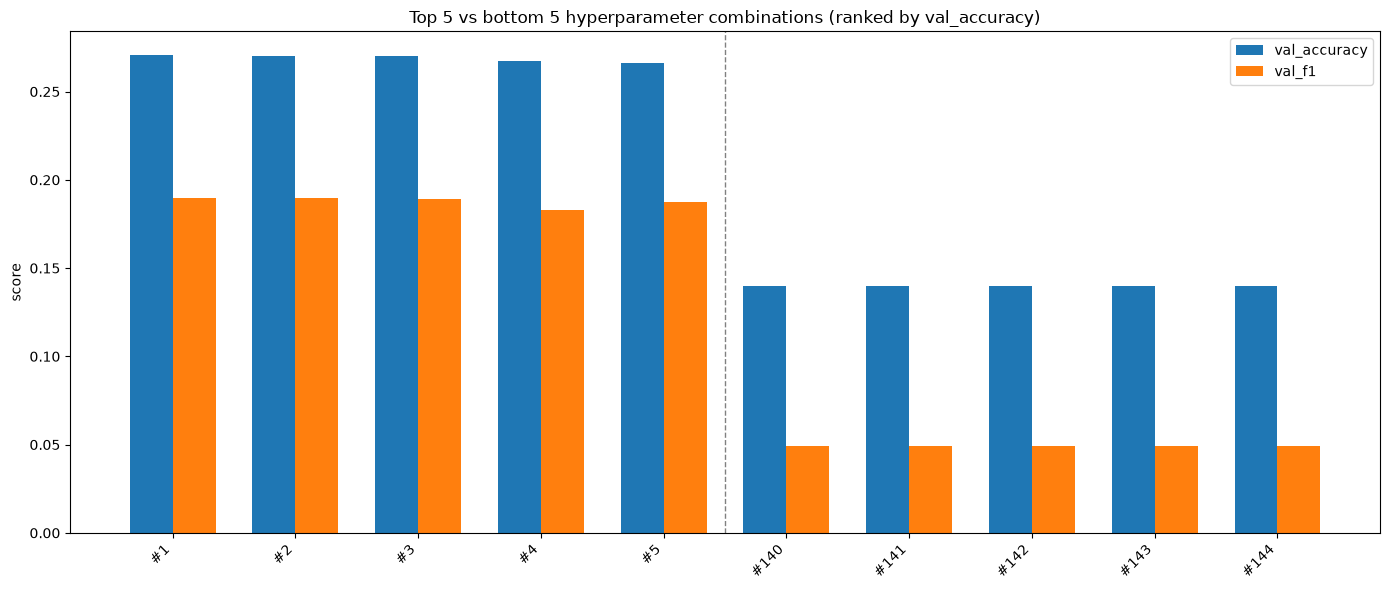

#1: {'max_depth': 20, 'min_samples_split': 2, 'max_features': None, 'ccp_alpha': 0.0, 'class_weight': None} -> val_accuracy=0.2706 val_f1=0.1899
#2: {'max_depth': 20, 'min_samples_split': 10, 'max_features': None, 'ccp_alpha': 0.0, 'class_weight': None} -> val_accuracy=0.2704 val_f1=0.1896
#3: {'max_depth': 20, 'min_samples_split': 20, 'max_features': None, 'ccp_alpha': 0.0, 'class_weight': None} -> val_accuracy=0.2704 val_f1=0.1893
#4: {'max_depth': 20, 'min_samples_split': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.0, 'class_weight': None} -> val_accuracy=0.2671 val_f1=0.1829
#5: {'max_depth': 20, 'min_samples_split': 10, 'max_features': 'sqrt', 'ccp_alpha': 0.0, 'class_weight': None} -> val_accuracy=0.2662 val_f1=0.1874
#140: {'max_depth': 20, 'min_samples_split': 10, 'max_features': 'sqrt', 'ccp_alpha': 0.1, 'class_weight': 'balanced'} -> val_accuracy=0.1396 val_f1=0.0490
#141: {'max_depth': 20, 'min_samples_split': 20, 'max_features': None, 'ccp_alpha': 0.01, 'class_weight': 'bala

In [20]:
# accuracy/F1 for the best and worst N hyperparameter combinations
N = 5
top = list(enumerate(results[:N], start=1))
bottom = list(enumerate(results[-N:], start=len(results) - N + 1))
selected = top + bottom

accs = [r["result"].val_accuracy for _, r in selected]
f1s = [r["result"].val_f1 for _, r in selected]
xpos = np.arange(len(selected))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(xpos - width / 2, accs, width, label="val_accuracy")
plt.bar(xpos + width / 2, f1s, width, label="val_f1")
plt.xticks(xpos, [f"#{rank}" for rank, _ in selected], rotation=45, ha="right")
plt.axvline(len(top) - 0.5, color="gray", linestyle="--", linewidth=1)
plt.ylabel("score")
plt.title(f"Top {N} vs bottom {N} hyperparameter combinations (ranked by val_accuracy)")
plt.legend()
plt.tight_layout()
plt.show()

for rank, r in selected:
    print(
        f"#{rank}: {r['overrides']} -> "
        f"val_accuracy={r['result'].val_accuracy:.4f} val_f1={r['result'].val_f1:.4f}"
    )

In [ ]:
# in-depth per-class precision/recall for the best combination
best_model = results[0]["result"].model
y_true = ytest.to_numpy()
y_pred = best_model.predict(xtest.to_numpy())

classes = sorted(np.unique(y_true))
class_names = [LABEL_NAMES[c] for c in classes]
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=classes)

xpos = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(xpos - width, precision, width, label="precision")
plt.bar(xpos, recall, width, label="recall")
plt.bar(xpos + width, f1, width, label="f1")
plt.xticks(xpos, class_names, rotation=20, ha="right")
plt.xlabel("return class")
plt.ylabel("score")
plt.title(f"Per-class precision/recall/F1 -- best combination (#1: {results[0]['overrides']})")
plt.legend()
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=classes, target_names=class_names))